# DermaXplain - 01 Data Inventory

This notebook focuses on **dataset inventory and data-quality diagnostics** for ISIC 2018 and HAM10000.

## Included
- path validation
- file-type checks
- optional `.txt` cleanup
- optional mask renaming cleanup
- image/mask stem matching
- image resolution statistics
- image-mask size consistency
- lesion mask coverage statistics
- border-touching and tiny-mask diagnostics
- HAM10000 metadata linkage
- clean inventory manifest export

## Datasets directory structure
Images datasets ISIC2018 and HAM10000 were downloaded from ISIC and reorganised into a common directory structure to facilitate image path references.
###  Dataset Storage (Local Only)

This folder contains datasets used for the **DermaXplain** practicum project.
**All contents of this directory are excluded from version control** and must be downloaded locally by each collaborator.

### Directory Structure
```
data/
|--- isic2018/
│    |--- images/
│    |--- masks/
|--- ham10000/
│    |--- images/
|    |--- masks/
│    |--- metadata.csv
```

In [31]:

from pathlib import Path
from collections import Counter
import shutil
import random

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 30)

In [32]:

ROOT = Path(".").resolve().parent if Path(".").resolve().name == "src" else Path(".").resolve()

ISIC_DIR = ROOT / "data" / "isic2018"
ISIC_IMG_DIR = ISIC_DIR / "images"
ISIC_MASK_DIR = ISIC_DIR / "masks"

HAM_DIR = ROOT / "data" / "ham10000"
HAM_IMG_DIR = HAM_DIR / "images"
HAM_MASK_DIR = HAM_DIR / "masks"
HAM_META = HAM_DIR / "HAM10000_metadata.csv"

assert ISIC_IMG_DIR.exists(), f"Missing {ISIC_IMG_DIR}"
assert ISIC_MASK_DIR.exists(), f"Missing {ISIC_MASK_DIR}"
assert HAM_IMG_DIR.exists(), f"Missing {HAM_IMG_DIR}"
assert HAM_MASK_DIR.exists(), f"Missing {HAM_MASK_DIR}"
assert HAM_META.exists(), f"Missing {HAM_META}"

print("ROOT:", ROOT.resolve())
print("ISIC image dir:", ISIC_IMG_DIR.resolve())
print("ISIC mask dir :", ISIC_MASK_DIR.resolve())
print("HAM image dir :", HAM_IMG_DIR.resolve())
print("HAM mask dir  :", HAM_MASK_DIR.resolve())
print("HAM metadata  :", HAM_META.resolve())

ROOT: /home/jessica/Projects/DCU/2026-mcm-XAI-skin-lesion
ISIC image dir: /home/jessica/Projects/DCU/2026-mcm-XAI-skin-lesion/data/isic2018/images
ISIC mask dir : /home/jessica/Projects/DCU/2026-mcm-XAI-skin-lesion/data/isic2018/masks
HAM image dir : /home/jessica/Projects/DCU/2026-mcm-XAI-skin-lesion/data/ham10000/images
HAM mask dir  : /home/jessica/Projects/DCU/2026-mcm-XAI-skin-lesion/data/ham10000/masks
HAM metadata  : /home/jessica/Projects/DCU/2026-mcm-XAI-skin-lesion/data/ham10000/HAM10000_metadata.csv


## Helper functions

In [33]:

def suffix_count(dir_path: Path):
    files = [p for p in dir_path.iterdir() if p.is_file()]
    return Counter(p.suffix.lower() for p in files)

def list_files(dir_path: Path, suffix: str) -> list[Path]:
    return sorted([p for p in dir_path.iterdir() if p.is_file() and p.suffix.lower() == suffix])

def stems(dir_path: Path, suffix: str) -> set[str]:
    return {p.stem for p in list_files(dir_path, suffix)}

def load_rgb_u8(path: Path) -> np.ndarray:
    return np.array(Image.open(path).convert("RGB"), dtype=np.uint8)

def load_mask_gray(path: Path) -> np.ndarray:
    return np.array(Image.open(path).convert("L"))

def load_mask_bin(path: Path) -> np.ndarray:
    return (load_mask_gray(path) > 0).astype(np.uint8)

def image_hw(path: Path) -> tuple[int, int]:
    with Image.open(path) as im:
        w, h = im.size
    return h, w

def mask_coverage(mask_path: Path) -> float:
    m = load_mask_bin(mask_path)
    return float(m.mean())

def overlay_mask(img_rgb: np.ndarray, mask_bin: np.ndarray, alpha: float = 0.4) -> np.ndarray:
    out = img_rgb.copy().astype(np.float32)
    red = np.zeros_like(out)
    red[..., 0] = 255
    lesion = mask_bin.astype(bool)
    out[lesion] = (1 - alpha) * out[lesion] + alpha * red[lesion]
    return out.astype(np.uint8)

## File-type checks

In [34]:

print("ISIC images:", suffix_count(ISIC_IMG_DIR))
print("ISIC masks :", suffix_count(ISIC_MASK_DIR))
print("HAM images :", suffix_count(HAM_IMG_DIR))
print("HAM masks  :", suffix_count(HAM_MASK_DIR))

ISIC images: Counter({'.jpg': 2594})
ISIC masks : Counter({'.png': 2594})
HAM images : Counter({'.jpg': 10015})
HAM masks  : Counter({'.png': 10015})


## Optional `.txt` cleanup

In [35]:

def move_txt_files(base_dir: Path):
    moved = []
    for sub in ["images", "masks"]:
        src_dir = base_dir / sub
        if not src_dir.exists():
            continue
        dest_dir = base_dir / "txt" / sub
        dest_dir.mkdir(parents=True, exist_ok=True)

        for p in src_dir.iterdir():
            if p.is_file() and p.suffix.lower() == ".txt":
                dest = dest_dir / p.name
                if not dest.exists():
                    shutil.move(str(p), str(dest))
                    moved.append((str(p), str(dest)))
    return moved

# Run only if needed:

# moved_isic = move_txt_files(ISIC_DIR)
# moved_ham = move_txt_files(HAM_DIR)
# print(f"ISIC moved txt files: {len(moved_isic)}")
# print(f"HAM moved txt files : {len(moved_ham)}")

## Optional mask renaming cleanup

In [36]:

def remove_segmentation_suffix(mask_dir: Path, dry_run: bool = False) -> list[tuple[str, str]]:
    renames = []
    for p in mask_dir.iterdir():
        if not p.is_file() or p.suffix.lower() != ".png":
            continue
        if not p.stem.endswith("_segmentation"):
            continue
        new_name = p.stem.removesuffix("_segmentation") + ".png"
        new_path = p.with_name(new_name)
        if new_path.exists():
            raise FileExistsError(f"Collision detected: {new_path}")
        renames.append((p.name, new_name))
        if not dry_run:
            p.rename(new_path)
    return renames

# Run only if needed # It should be done already, if you use the google share drive links to download the data.
# renames_isic = remove_segmentation_suffix(ISIC_MASK_DIR, dry_run=False)
# renames_ham  = remove_segmentation_suffix(HAM_MASK_DIR, dry_run=False)

## Dataset inventory and stem matching

In [37]:

isic_img_stems = stems(ISIC_IMG_DIR, ".jpg")
isic_mask_stems = stems(ISIC_MASK_DIR, ".png")
isic_pairs = isic_img_stems & isic_mask_stems
isic_img_only = sorted(isic_img_stems - isic_mask_stems)
isic_mask_only = sorted(isic_mask_stems - isic_img_stems)

ham_img_stems = stems(HAM_IMG_DIR, ".jpg")
ham_mask_stems = stems(HAM_MASK_DIR, ".png")
ham_pairs = ham_img_stems & ham_mask_stems
ham_img_only = sorted(ham_img_stems - ham_mask_stems)
ham_mask_only = sorted(ham_mask_stems - ham_img_stems)

inventory_summary = pd.DataFrame([
    {
        "dataset": "ISIC 2018",
        "images": len(isic_img_stems),
        "masks": len(isic_mask_stems),
        "matched_pairs": len(isic_pairs),
        "image_only": len(isic_img_only),
        "mask_only": len(isic_mask_only)
    },
    {
        "dataset": "HAM10000",
        "images": len(ham_img_stems),
        "masks": len(ham_mask_stems),
        "matched_pairs": len(ham_pairs),
        "image_only": len(ham_img_only),
        "mask_only": len(ham_mask_only)
    }
])
display(inventory_summary)

,dataset,images,masks,matched_pairs,image_only,mask_only
0,ISIC 2018,2594,2594,2594,0,0
1,HAM10000,10015,10015,10015,0,0


## Image resolution statistics

In [38]:

def resolution_df(img_dir: Path, suffix: str) -> pd.DataFrame:
    rows = []
    for p in list_files(img_dir, suffix):
        h, w = image_hw(p)
        rows.append({
            "stem": p.stem,
            "height": h,
            "width": w,
            "pixels": h * w,
            "aspect_ratio": w / h
        })
    return pd.DataFrame(rows)

isic_res = resolution_df(ISIC_IMG_DIR, ".jpg")
ham_res = resolution_df(HAM_IMG_DIR, ".jpg")

display(isic_res[["height", "width", "pixels", "aspect_ratio"]].describe())
display(ham_res[["height", "width", "pixels", "aspect_ratio"]].describe())

,height,width,pixels,aspect_ratio
count,2594.000000,2594.000000,2.594000e+03,2594.000000
mean,2166.791442,3188.266384,9.291571e+06,1.431942
std,1241.344101,1923.091567,9.510341e+06,0.100596
min,540.000000,576.000000,3.843140e+05,0.750000
25%,768.000000,1024.000000,7.864320e+05,1.333333
50%,2000.000000,3008.000000,6.016000e+06,1.500000
75%,2848.000000,4288.000000,1.221222e+07,1.505618
max,4499.000000,6748.000000,3.035925e+07,1.546474


,height,width,pixels,aspect_ratio
count,10015.0,10015.0,10015.0,1.001500e+04
mean,450.0,600.0,270000.0,1.333333e+00
std,0.0,0.0,0.0,2.220557e-16
min,450.0,600.0,270000.0,1.333333e+00
25%,450.0,600.0,270000.0,1.333333e+00
50%,450.0,600.0,270000.0,1.333333e+00
75%,450.0,600.0,270000.0,1.333333e+00
max,450.0,600.0,270000.0,1.333333e+00


## Image-mask size consistency

In [39]:

def pair_size_check(img_dir: Path, mask_dir: Path, img_suffix=".jpg", mask_suffix=".png") -> pd.DataFrame:
    common = sorted(stems(img_dir, img_suffix) & stems(mask_dir, mask_suffix))
    rows = []
    for stem in common:
        img_path = img_dir / f"{stem}{img_suffix}"
        mask_path = mask_dir / f"{stem}{mask_suffix}"
        img_h, img_w = image_hw(img_path)
        mask_h, mask_w = image_hw(mask_path)
        rows.append({
            "stem": stem,
            "img_h": img_h,
            "img_w": img_w,
            "mask_h": mask_h,
            "mask_w": mask_w,
            "same_size": (img_h == mask_h) and (img_w == mask_w)
        })
    return pd.DataFrame(rows)

isic_pair_sizes = pair_size_check(ISIC_IMG_DIR, ISIC_MASK_DIR)
ham_pair_sizes = pair_size_check(HAM_IMG_DIR, HAM_MASK_DIR)

display(isic_pair_sizes["same_size"].value_counts())
display(ham_pair_sizes["same_size"].value_counts())

same_size
True    2594
Name: count, dtype: int64

same_size
True    10015
Name: count, dtype: int64

## Mask coverage statistics

ISIC mask coverage summary:


count    2594.000000
mean        0.214021
std         0.208366
min         0.002977
25%         0.051731
50%         0.138084
75%         0.318733
max         0.986650
Name: mask_coverage, dtype: float64

HAM mask coverage summary:


count    10015.000000
mean         0.266325
std          0.188419
min          0.003856
25%          0.119504
50%          0.222307
75%          0.374139
max          1.000000
Name: mask_coverage, dtype: float64

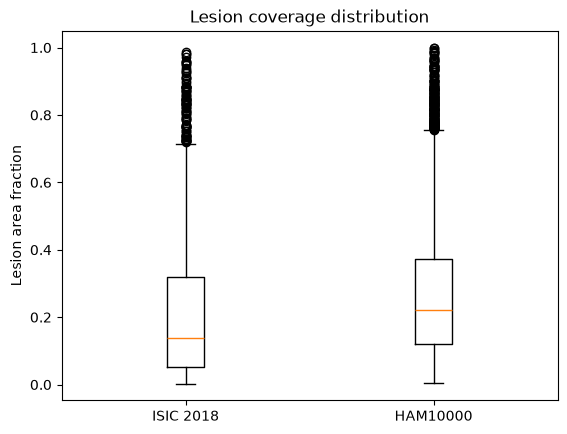

In [40]:

def coverage_df(mask_dir: Path, suffix: str) -> pd.DataFrame:
    rows = []
    for p in list_files(mask_dir, suffix):
        rows.append({
            "stem": p.stem,
            "mask_coverage": mask_coverage(p)
        })
    return pd.DataFrame(rows)

isic_cov = coverage_df(ISIC_MASK_DIR, ".png")
ham_cov = coverage_df(HAM_MASK_DIR, ".png")

print("ISIC mask coverage summary:")
display(isic_cov["mask_coverage"].describe())

print("HAM mask coverage summary:")
display(ham_cov["mask_coverage"].describe())

plt.boxplot([isic_cov.mask_coverage, ham_cov.mask_coverage], tick_labels=["ISIC 2018", "HAM10000"])
plt.ylabel("Lesion area fraction")
plt.title("Lesion coverage distribution")
plt.show()

## HAM10000 metadata and class distribution

In [41]:

ham_meta = pd.read_csv(HAM_META)
display(ham_meta.head())
display(ham_meta["dx"].value_counts())

ham_meta["label"] = (ham_meta["dx"] == "mel").astype(int)
ham_meta["label_name"] = ham_meta["dx"].apply(lambda x: "melanoma" if x == "mel" else "non-melanoma")
display(ham_meta["label_name"].value_counts())

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern


dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

label_name
non-melanoma    8902
melanoma        1113
Name: count, dtype: int64

## Additional mask diagnostics

In [42]:

def border_touch_info(mask_path: Path) -> dict:
    mask = load_mask_bin(mask_path)
    top = bool(mask[0, :].any())
    bottom = bool(mask[-1, :].any())
    left = bool(mask[:, 0].any())
    right = bool(mask[:, -1].any())
    n_borders_touched = sum([top, bottom, left, right])
    return {
        "stem": mask_path.stem,
        "touch_top": top,
        "touch_bottom": bottom,
        "touch_left": left,
        "touch_right": right,
        "touches_any_border": n_borders_touched > 0,
        "n_borders_touched": n_borders_touched
    }

def border_touch_df(mask_dir: Path, suffix=".png") -> pd.DataFrame:
    return pd.DataFrame([border_touch_info(mask_path) for mask_path in list_files(mask_dir, suffix)])

def classify_mask_size(coverage: float) -> str:
    if coverage < 0.01:
        return "very_tiny"
    elif coverage < 0.02:
        return "tiny"
    elif coverage < 0.05:
        return "small"
    else:
        return "normal"

isic_border = border_touch_df(ISIC_MASK_DIR)
ham_border = border_touch_df(HAM_MASK_DIR)

isic_cov["mask_size_class"] = isic_cov["mask_coverage"].apply(classify_mask_size)
ham_cov["mask_size_class"] = ham_cov["mask_coverage"].apply(classify_mask_size)

display(isic_border["touches_any_border"].value_counts())
display(ham_border["touches_any_border"].value_counts())
display(isic_cov["mask_size_class"].value_counts())
display(ham_cov["mask_size_class"].value_counts())

touches_any_border
False    2388
True      206
Name: count, dtype: int64

touches_any_border
False    8421
True     1594
Name: count, dtype: int64

mask_size_class
normal       1970
small         427
tiny          149
very_tiny      48
Name: count, dtype: int64

mask_size_class
normal       9284
small         544
tiny          136
very_tiny      51
Name: count, dtype: int64

## Build inventory manifests

In [43]:

def build_inventory(img_dir: Path, mask_dir: Path, img_suffix=".jpg", mask_suffix=".png") -> pd.DataFrame:
    img_stems = stems(img_dir, img_suffix)
    mask_stems = stems(mask_dir, mask_suffix)
    all_stems = sorted(img_stems | mask_stems)

    rows = []
    for stem in all_stems:
        img_exists = stem in img_stems
        mask_exists = stem in mask_stems

        row = {
            "stem": stem,
            "image_exists": img_exists,
            "mask_exists": mask_exists
        }

        if img_exists:
            img_path = img_dir / f"{stem}{img_suffix}"
            img_h, img_w = image_hw(img_path)
            row["img_h"] = img_h
            row["img_w"] = img_w
            row["pixels"] = img_h * img_w
            row["aspect_ratio"] = img_w / img_h
        else:
            row["img_h"] = np.nan
            row["img_w"] = np.nan
            row["pixels"] = np.nan
            row["aspect_ratio"] = np.nan

        if mask_exists:
            mask_path = mask_dir / f"{stem}{mask_suffix}"
            mask_h, mask_w = image_hw(mask_path)
            cov = mask_coverage(mask_path)
            row["mask_h"] = mask_h
            row["mask_w"] = mask_w
            row["mask_coverage"] = cov
            row["mask_pixels"] = int(round(cov * mask_h * mask_w))
            row["mask_size_class"] = classify_mask_size(cov)
        else:
            row["mask_h"] = np.nan
            row["mask_w"] = np.nan
            row["mask_coverage"] = np.nan
            row["mask_pixels"] = np.nan
            row["mask_size_class"] = np.nan

        row["same_size"] = (
            img_exists and mask_exists and
            row["img_h"] == row["mask_h"] and
            row["img_w"] == row["mask_w"]
        )
        rows.append(row)
    return pd.DataFrame(rows)

isic_inventory = build_inventory(ISIC_IMG_DIR, ISIC_MASK_DIR)
ham_inventory = build_inventory(HAM_IMG_DIR, HAM_MASK_DIR)

isic_inventory = isic_inventory.merge(isic_border, on="stem", how="left")
ham_inventory = ham_inventory.merge(ham_border, on="stem", how="left")

# Preserve lesion_id so repeated views of the same biological lesion
# can be kept together during later train/validation splitting.
required_metadata_cols = ["image_id", "lesion_id", "dx", "label", "label_name"]
missing_metadata_cols = [c for c in required_metadata_cols if c not in ham_meta.columns]
if missing_metadata_cols:
    raise ValueError(f"HAM metadata is missing required columns: {missing_metadata_cols}")

ham_inventory = ham_inventory.merge(
    ham_meta[required_metadata_cols],
    left_on="stem",
    right_on="image_id",
    how="left",
    validate="one_to_one",
).drop(columns=["image_id"])

matched_rows = ham_inventory["lesion_id"].notna().sum()
print(f"HAM metadata matches with lesion_id: {matched_rows}/{len(ham_inventory)}")

if matched_rows != len(ham_inventory):
    missing_stems = ham_inventory.loc[ham_inventory["lesion_id"].isna(), "stem"].tolist()
    raise ValueError(
        "Some HAM images did not match HAM10000_metadata.csv. "
        f"First missing stems: {missing_stems[:10]}"
    )

display(isic_inventory.head())
display(ham_inventory[["stem", "lesion_id", "dx", "label_name"]].head())


HAM metadata matches with lesion_id: 10015/10015


,stem,image_exists,mask_exists,img_h,img_w,pixels,aspect_ratio,mask_h,mask_w,mask_coverage,mask_pixels,mask_size_class,same_size,touch_top,touch_bottom,touch_left,touch_right,touches_any_border,n_borders_touched
0,ISIC_0000000,True,True,767,1022,783874,1.332464,767,1022,0.469732,368211,normal,True,False,False,False,False,False,0
1,ISIC_0000001,True,True,767,1022,783874,1.332464,767,1022,0.070504,55266,normal,True,False,False,False,False,False,0
2,ISIC_0000003,True,True,767,1022,783874,1.332464,767,1022,0.336569,263828,normal,True,False,False,False,False,False,0
3,ISIC_0000004,True,True,767,1022,783874,1.332464,767,1022,0.344974,270416,normal,True,False,False,False,False,False,0
4,ISIC_0000006,True,True,767,1022,783874,1.332464,767,1022,0.091723,71899,normal,True,False,False,False,False,False,0


,stem,lesion_id,dx,label_name
0,ISIC_0024306,HAM_0000550,nv,non-melanoma
1,ISIC_0024307,HAM_0003577,nv,non-melanoma
2,ISIC_0024308,HAM_0001477,nv,non-melanoma
3,ISIC_0024309,HAM_0000484,nv,non-melanoma
4,ISIC_0024310,HAM_0003350,mel,melanoma


In [44]:

def inventory_diagnostic_summary(df: pd.DataFrame, name: str):
    print(f"\n{name} - same_size")
    display(df["same_size"].value_counts())

    print(f"{name} - mask_size_class")
    display(df["mask_size_class"].value_counts())

    print(f"{name} - touches_any_border")
    display(df["touches_any_border"].value_counts())

    print(f"{name} - n_borders_touched")
    display(df["n_borders_touched"].value_counts().sort_index())

    print(f"{name} - border-touch rate")
    print(f"{100 * df['touches_any_border'].mean():.2f}%")

inventory_diagnostic_summary(isic_inventory, "ISIC")
inventory_diagnostic_summary(ham_inventory, "HAM")


ISIC - same_size


same_size
True    2594
Name: count, dtype: int64

ISIC - mask_size_class


mask_size_class
normal       1970
small         427
tiny          149
very_tiny      48
Name: count, dtype: int64

ISIC - touches_any_border


...

HAM - touches_any_border


touches_any_border
False    8421
True     1594
Name: count, dtype: int64

HAM - n_borders_touched


n_borders_touched
0    8421
1     908
2     396
3     183
4     107
Name: count, dtype: int64

HAM - border-touch rate
15.92%


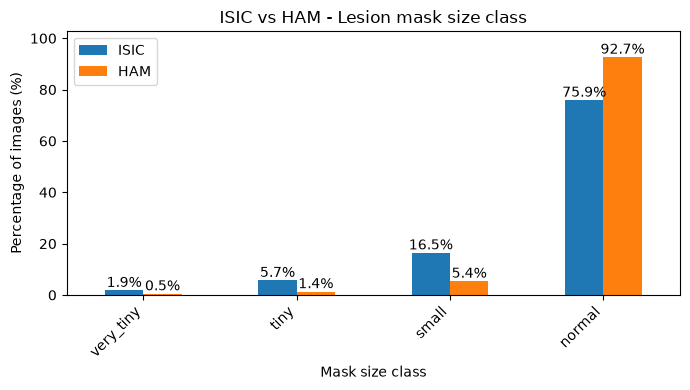

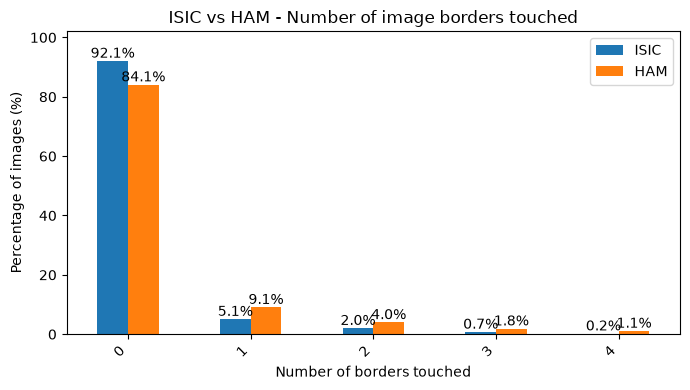

In [45]:
# Plots for mask size class distribution and border-touch rate.


MASK_SIZE_ORDER = ["very_tiny", "tiny", "small", "normal"]
BOOLEAN_ORDER = [False, True]


def percentage_counts(df: pd.DataFrame, column: str, order=None) -> pd.Series:
    """
    Return value counts as percentages.
    """
    pct = df[column].value_counts(normalize=True, dropna=False) * 100

    if order is not None:
        pct = pct.reindex(order, fill_value=0)

    return pct


def plot_isic_ham_percent_comparison(
    isic_df: pd.DataFrame,
    ham_df: pd.DataFrame,
    column: str,
    title: str,
    order=None,
    xlabel=None,
    figsize=(7, 4),
):
    """
    Plot ISIC and HAM percentages side by side for the same categorical column.
    """

    isic_pct = percentage_counts(isic_df, column, order=order)
    ham_pct = percentage_counts(ham_df, column, order=order)

    plot_df = pd.DataFrame({
        "ISIC": isic_pct,
        "HAM": ham_pct,
    })

    ax = plot_df.plot(kind="bar", figsize=figsize)

    ax.set_title(title)
    ax.set_xlabel(xlabel if xlabel else column)
    ax.set_ylabel("Percentage of images (%)")
    ax.set_ylim(0, max(plot_df.max()) + 10)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%")

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


# Plot mask size class distribution comparison
plot_isic_ham_percent_comparison(
    isic_inventory,
    ham_inventory,
    column="mask_size_class",
    title="ISIC vs HAM - Lesion mask size class",
    order=MASK_SIZE_ORDER,
    xlabel="Mask size class",
)

'''01_data_inventory.ipynb# Plot border-touch rate comparison
plot_isic_ham_percent_comparison(
    isic_inventory,
    ham_inventory,
    column="touches_any_border",
    title="ISIC vs HAM - Lesion touches image border",
    order=BOOLEAN_ORDER,
    xlabel="Touches any border",
)
''' 
# Plot number of borders touched comparison
plot_isic_ham_percent_comparison(
    isic_inventory,
    ham_inventory,
    column="n_borders_touched",
    title="ISIC vs HAM - Number of image borders touched",
    order=[0, 1, 2, 3, 4],
    xlabel="Number of borders touched",
)

## Gallery

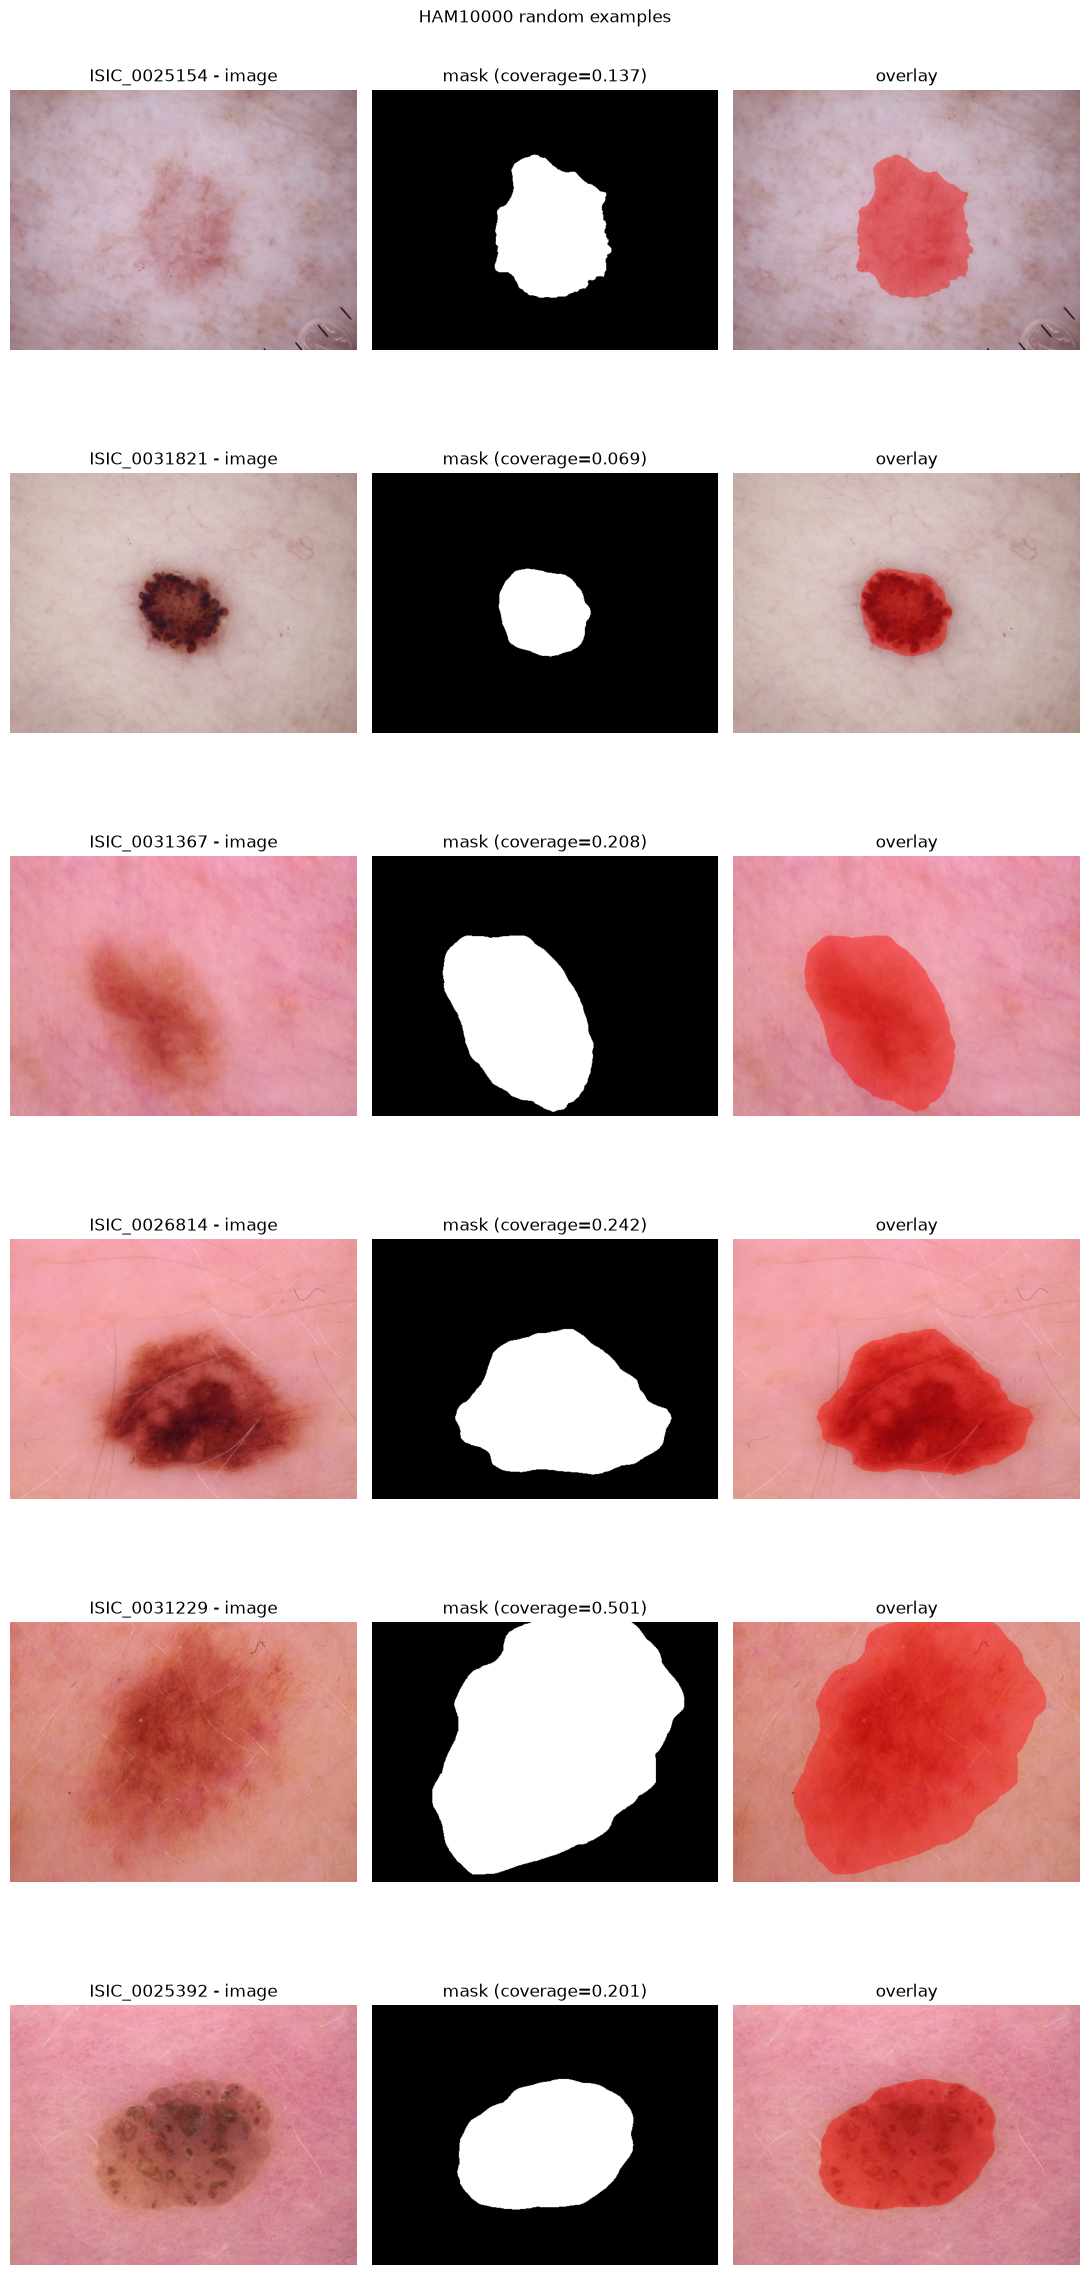

In [46]:

def show_triplets(stems_list, img_dir: Path, mask_dir: Path, n=6, title="Gallery"):
    chosen = stems_list[:n]
    fig, axes = plt.subplots(len(chosen), 3, figsize=(11, 4 * len(chosen)))
    if len(chosen) == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, stem in enumerate(chosen):
        img = load_rgb_u8(img_dir / f"{stem}.jpg")
        mask = load_mask_bin(mask_dir / f"{stem}.png")
        overlay = overlay_mask(img, mask, alpha=0.4)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"{stem} - image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask, cmap="gray")
        axes[i, 1].set_title(f"mask (coverage={mask.mean():.3f})")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title("overlay")
        axes[i, 2].axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

random_ham_stems = random.sample(sorted(list(ham_pairs)), min(6, len(ham_pairs)))
show_triplets(random_ham_stems, HAM_IMG_DIR, HAM_MASK_DIR, n=len(random_ham_stems), title="HAM10000 random examples")

## Save clean inventory manifests

In [47]:

OUT_DIR = ROOT / "data" / "preprocessed_manifests"
OUT_DIR.mkdir(parents=True, exist_ok=True)

isic_inventory_path = OUT_DIR / "isic2018_inventory.csv"
ham_inventory_path = OUT_DIR / "ham10000_inventory.csv"

assert "lesion_id" in ham_inventory.columns
assert ham_inventory["lesion_id"].notna().all()

isic_inventory.to_csv(isic_inventory_path, index=False)
ham_inventory.to_csv(ham_inventory_path, index=False)

print("Saved:", isic_inventory_path.resolve())
print("Saved:", ham_inventory_path.resolve())
print("Unique HAM images :", ham_inventory["stem"].nunique())
print("Unique HAM lesions:", ham_inventory["lesion_id"].nunique())
print(
    "Lesions with multiple images:",
    int((ham_inventory.groupby("lesion_id").size() > 1).sum()),
)


Saved: /home/jessica/Projects/DCU/2026-mcm-XAI-skin-lesion/data/preprocessed_manifests/isic2018_inventory.csv
Saved: /home/jessica/Projects/DCU/2026-mcm-XAI-skin-lesion/data/preprocessed_manifests/ham10000_inventory.csv
Unique HAM images : 10015
Unique HAM lesions: 7470
Lesions with multiple images: 1956
